In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import copy
import math

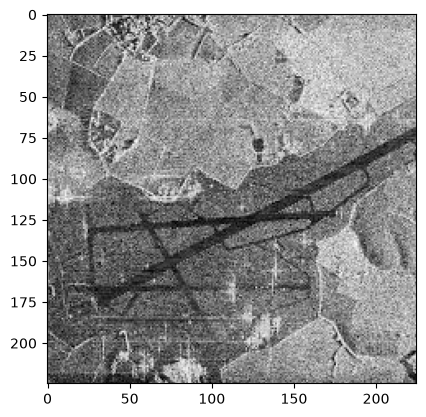

In [2]:
image = cv2.imread('sar_3.jpg')

image_gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
image_gray = cv2.GaussianBlur(image_gray, (7, 7), 0)

plt.imshow(image, cmap="gray")

# Детектор границ Кэнни

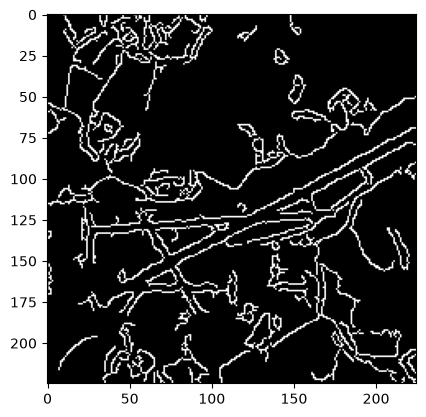

In [3]:
canny = cv2.Canny(image_gray, 50, 150, apertureSize=3)

plt.imshow(canny, cmap="gray")

# Преобразование Хафа

Наиболее протяжённый участок: (19, 176) -> (221, 69), длина = 228.59 пикселей


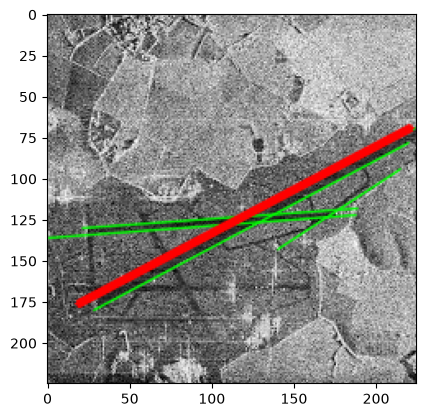

In [4]:
lines = cv2.HoughLinesP(canny, 1, np.pi / 180, 70, minLineLength=20, maxLineGap=23)

image_copy = image.copy()

longest_line = None
max_len = 0

for i in range(0, len(lines)):
    x1, y1, x2, y2 = lines[i]

    length = math.sqrt((x2 - x1) ** 2 + (y2 - y1) ** 2)

    if length > max_len:
        max_len = length
        longest_line = (x1, y1, x2, y2)

    cv2.line(image_copy, (x1, y1), (x2, y2), (0, 255, 0), 1, cv2.LINE_AA)

x1, y1, x2, y2 = longest_line
cv2.line(image_copy, (x1, y1), (x2, y2), (0, 0, 255), 3, cv2.LINE_AA)
print(f"Наиболее протяжённый участок: ({x1}, {y1}) -> ({x2}, {y2}), длина = {max_len:.2f} пикселей")

plt.imshow(cv2.cvtColor(image_copy, cv2.COLOR_BGR2RGB))

# Точечная бинаризация

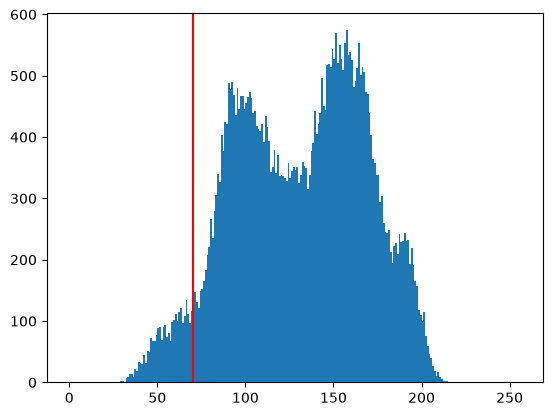

In [5]:
b_img = copy.deepcopy(image_gray)
T  = 70

b_img[image_gray < T] = 0
b_img[image_gray >= T] = 255

plt.hist(image_gray.ravel(), bins=256, range=(0, 256))
plt.axvline(T, color='r')
plt.show()

# Бинаризация Отсу

In [6]:
_,th2 = cv2.threshold(image_gray,0,255,cv2.THRESH_BINARY+cv2.THRESH_OTSU)

# Адаптивная бинаризация

In [7]:
th3 = cv2.adaptiveThreshold(image_gray,255,cv2.ADAPTIVE_THRESH_GAUSSIAN_C,\
            cv2.THRESH_BINARY,301,41)

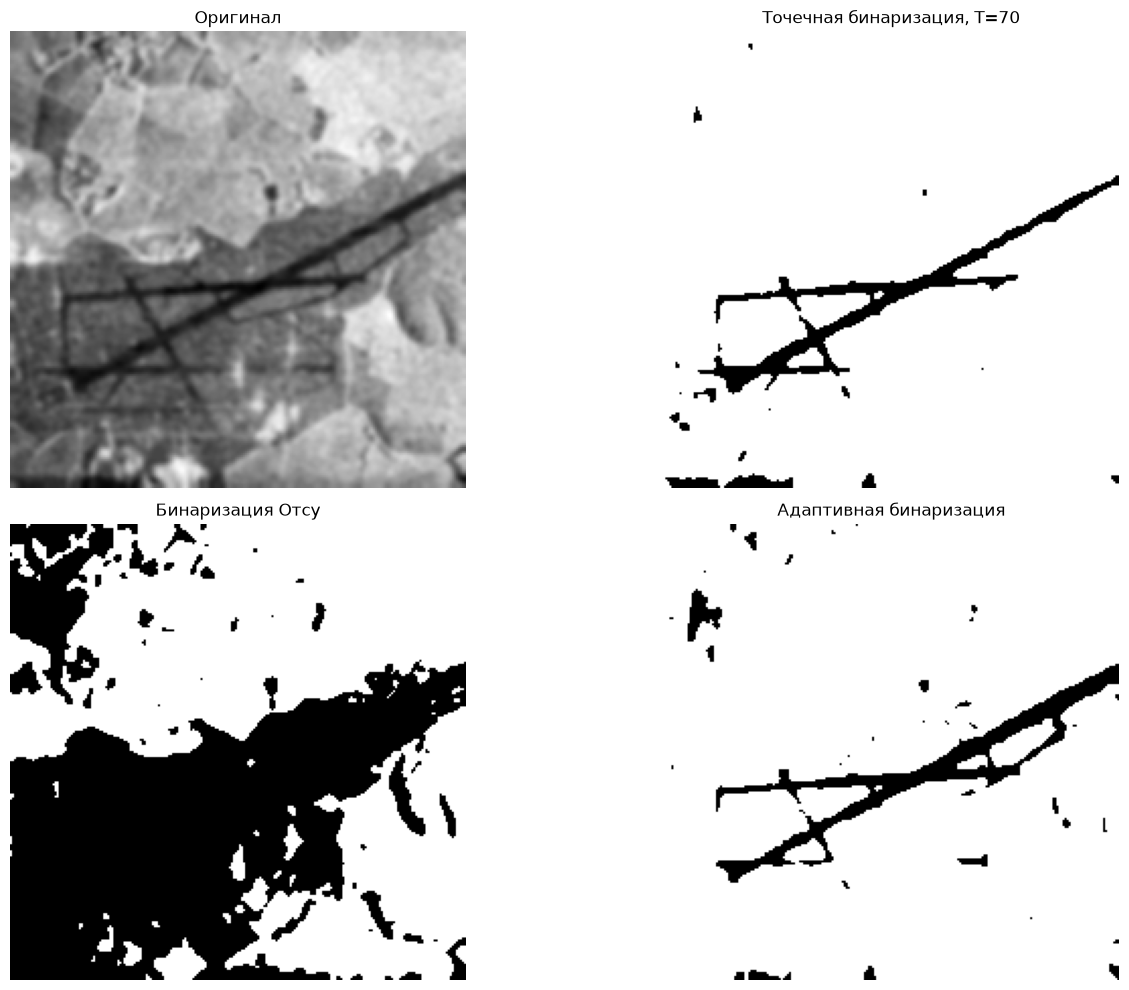

In [8]:
plt.figure(figsize=(15, 10))

plt.subplot(2, 2, 1)
plt.imshow(image_gray, cmap="gray")
plt.title("Оригинал")
plt.axis('off')

plt.subplot(2, 2, 2)
plt.imshow(b_img, cmap="gray")
plt.title(f"Точечная бинаризация, T={T}")
plt.axis('off')

plt.subplot(2, 2, 3)
plt.imshow(th2, cmap="gray")
plt.title("Бинаризация Отсу")
plt.axis('off')

plt.subplot(2, 2, 4)
plt.imshow(th3, cmap="gray")
plt.title("Адаптивная бинаризация")
plt.axis('off')

plt.tight_layout()
plt.show()

Более точный участок дороги выделяют алгоритмы точечной бинаризации с параметром 70 и адаптивной бинаризации с параметрами 301, 41. Бинаризация Отсу показал более слабый результат.